In [4]:
import pandas as pd # Для работы с таблицами (DataFrames)
import numpy as np  # Для математических операций
import os           # Для работы с файловой системой
import glob         # Для удобного поиска файлов по маске (например, все .csv)
import lightgbm as lgb # Сам алгоритм градиентного бустинга
from sklearn.model_selection import train_test_split # Для деления данных на обучение и тест
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # Метрики
import matplotlib.pyplot as plt # Для графиков
import seaborn as sns # Для красивых матриц корреляции


In [5]:
# Укажите путь к папке, где лежит датасет (папки устройств)
DATASET_PATH = '/home/lolkek3310/python/Подготовка Гомель/боты/N-BaIoT' 

# Сколько строк брать из КАЖДОГО файла. 
# В датасете миллионы строк, 10000 достаточно для отличного обучения.
SAMPLE_SIZE = 10000

In [6]:
def load_and_label_data_flat(base_path, rows_per_file):
    combined_list = []
    
    # Получаем список всех CSV файлов прямо в папке N-BaIoT
    # Мы ищем все файлы, заканчивающиеся на .csv
    all_files = glob.glob(os.path.join(base_path, "*.csv"))
    
    print(f"Всего файлов найдено: {len(all_files)}")
    
    for file_path in all_files:
        file_name = os.path.basename(file_path)
        
        # Пропускаем служебные файлы датасета, которые не содержат трафик
        if file_name in ['data_summary.csv', 'device_info.csv', 'features.csv']:
            print(f"Пропускаем служебный файл: {file_name}")
            continue
            
        # Читаем CSV
        try:
            temp_df = pd.read_csv(file_path)
            
            # Если файл пустой — пропускаем
            if temp_df.empty:
                continue
                
            # Берем случайную выборку для экономии памяти
            sample_n = min(len(temp_df), rows_per_file)
            temp_df = temp_df.sample(n=sample_n, random_state=42)
            
            # ОПРЕДЕЛЕНИЕ МЕТКИ (Target):
            # Если в названии файла есть слово 'benign', это норма (0)
            # В противном случае (mirai, gafgyt) это атака (1)
            if 'benign' in file_name:
                temp_df['target'] = 0
            else:
                temp_df['target'] = 1
                
            combined_list.append(temp_df)
            print(f"Загружен файл: {file_name} | Строк: {sample_n} | Класс: {temp_df['target'].iloc[0]}")
            
        except Exception as e:
            print(f"Ошибка при чтении {file_name}: {e}")
            
    if not combined_list:
        raise ValueError("Не удалось загрузить ни одного файла. Проверьте путь и расширения.")
        
    return pd.concat(combined_list, ignore_index=True)

# Запускаем загрузку (путь у тебя уже указан в DATASET_PATH)
df = load_and_label_data_flat(DATASET_PATH, SAMPLE_SIZE)

print("\n--- ИТОГО ---")
print(f"Общее количество строк: {df.shape[0]}")
print(f"Распределение классов:\n{df['target'].value_counts()}")

Всего файлов найдено: 92
Загружен файл: 1.benign.csv | Строк: 10000 | Класс: 0
Загружен файл: 1.gafgyt.combo.csv | Строк: 10000 | Класс: 1
Загружен файл: 1.gafgyt.junk.csv | Строк: 10000 | Класс: 1
Загружен файл: 1.gafgyt.scan.csv | Строк: 10000 | Класс: 1
Загружен файл: 1.gafgyt.tcp.csv | Строк: 10000 | Класс: 1
Загружен файл: 1.gafgyt.udp.csv | Строк: 10000 | Класс: 1
Загружен файл: 1.mirai.ack.csv | Строк: 10000 | Класс: 1
Загружен файл: 1.mirai.scan.csv | Строк: 10000 | Класс: 1
Загружен файл: 1.mirai.syn.csv | Строк: 10000 | Класс: 1
Загружен файл: 1.mirai.udp.csv | Строк: 10000 | Класс: 1
Загружен файл: 1.mirai.udpplain.csv | Строк: 10000 | Класс: 1
Загружен файл: 2.benign.csv | Строк: 10000 | Класс: 0
Загружен файл: 2.gafgyt.combo.csv | Строк: 10000 | Класс: 1
Загружен файл: 2.gafgyt.junk.csv | Строк: 10000 | Класс: 1
Загружен файл: 2.gafgyt.scan.csv | Строк: 10000 | Класс: 1
Загружен файл: 2.gafgyt.tcp.csv | Строк: 10000 | Класс: 1
Загружен файл: 2.gafgyt.udp.csv | Строк: 10000

Удалено 64 лишних признаков. Осталось 52


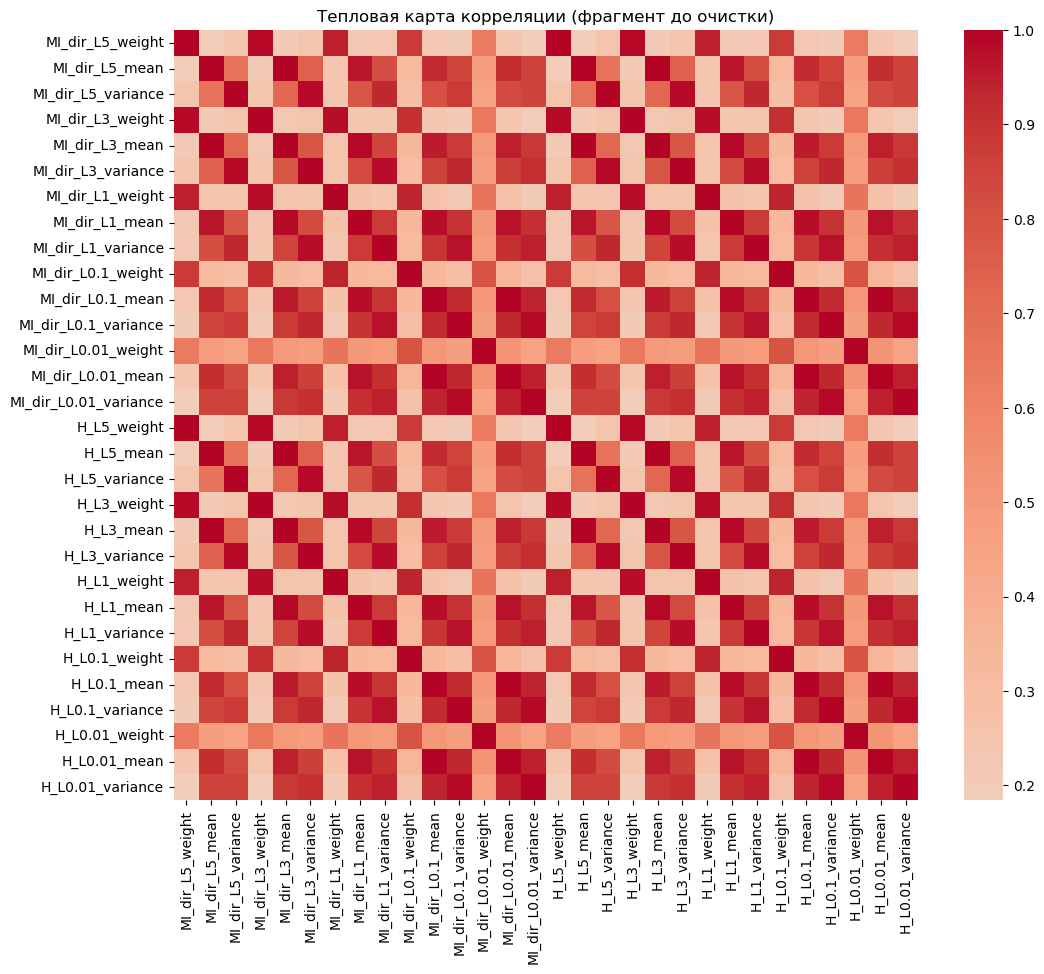

In [ ]:
# Считаем матрицу корреляции только для признаков (без колонки target)
corr_matrix = df.drop('target', axis=1).corr().abs()

# Выбираем только верхнюю часть матрицы (над диагональю)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Находим названия колонок, корреляция которых выше 98%
to_drop = [column for column in upper.columns if any(upper[column] > 0.98)]

# Удаляем их из таблицы
df_final = df.drop(to_drop, axis=1)
print(f"Удалено {len(to_drop)} лишних признаков. Осталось {df_final.shape[1]}")


In [8]:
# X - это характеристики трафика, y - метка (норма/атака)
X = df_final.drop('target', axis=1)
y = df_final['target']

# Разделяем на тренировочную (80%) и тестовую (20%) выборки
# stratify=y гарантирует, что процент атак будет одинаков в обеих частях
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [9]:
model = lgb.LGBMClassifier(
    n_estimators=1000,      # Построить 1000 деревьев решений последовательно
    learning_rate=0.05,     # Скорость обучения (маленький шаг дает больше точности)
    num_leaves=31,          # Количество узлов в каждом дереве
    class_weight='balanced',# Уравновешивает классы (если атак в 10 раз больше, чем нормы)
    objective='binary',     # Тип задачи: бинарная классификация
    random_state=42,        # Фиксация случайности для повторяемости результата
    n_jobs=-1               # Использовать все ядра процессора для скорости
)

In [10]:
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)], # На чем проверять качество в процессе
    eval_metric='logloss'        # Метрика ошибки
)

[LightGBM] [Info] Number of positive: 640000, number of negative: 72000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.184527 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13005
[LightGBM] [Info] Number of data points in the train set: 712000, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20



--- Отчет о работе модели ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18000
           1       1.00      1.00      1.00    160000

    accuracy                           1.00    178000
   macro avg       1.00      1.00      1.00    178000
weighted avg       1.00      1.00      1.00    178000



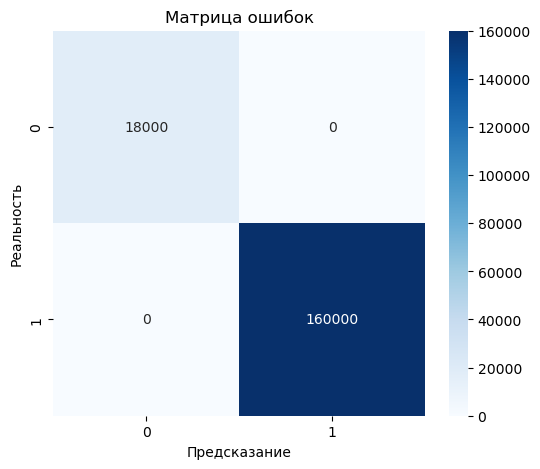

In [11]:
# Получаем финальные предсказания
y_pred = model.predict(X_test)

# Выводим текстовый отчет (Точность, Полнота, F1)
print("\n--- Отчет о работе модели ---")
print(classification_report(y_test, y_pred))

# Строим матрицу ошибок визуально
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')
plt.ylabel('Реальность')
plt.xlabel('Предсказание')
plt.show()

<Figure size 1000x800 with 0 Axes>

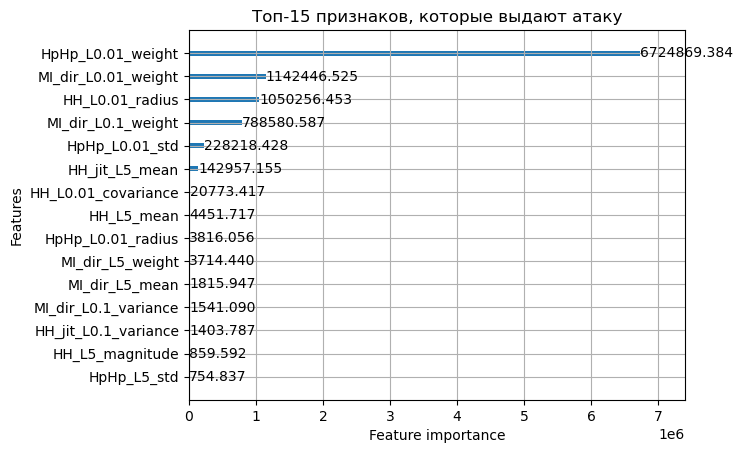

In [12]:
# Строим график 15 самых важных колонок
plt.figure(figsize=(10, 8))
lgb.plot_importance(model, max_num_features=15, importance_type='gain')
plt.title('Топ-15 признаков, которые выдают атаку')
plt.show()

Давай подведем итог всей проделанной работы. Мы превратили "кучу файлов" в работающую систему кибербезопасности.

Вот подробная хронология того, что мы сделали, как это работает и какой результат ты получил.

---

### 1. Этап "Сбор улик" (Загрузка данных)
**Что сделали:** Мы написали скрипт, который просканировал твою папку `N-BaIoT`, открыл каждый файл (от `1.benign.csv` до `9.mirai.udp.csv`) и собрал их в одну огромную таблицу.
**Зачем это нужно:** Нейросети или алгоритмы бустинга (как LightGBM) не умеют учиться на файлах по отдельности. Им нужна одна большая база данных.
**Что получили:** Объект `df` — таблицу, где в строках записаны параметры сетевых пакетов, а в последней колонке `target` стоит ответ: `0` (безопасно) или `1` (атака).

---

### 2. Этап "Фильтрация шума" (Очистка корреляции)
**Что сделали:** Мы вычислили "матрицу корреляции". Это способ узнать, какие колонки говорят об одном и том же. Например, если две колонки меняются абсолютно одинаково, одна из них лишняя. Мы удалили те, которые совпадали более чем на 98%.
**Зачем это нужно:**
1. Чтобы модель работала **быстрее** (меньше колонок — меньше вычислений).
2. Чтобы избежать **переобучения** (когда модель "зазубривает" мусорные признаки).
**Что получили:** Компактный набор данных, где остались только самые уникальные и важные характеристики трафика.

---

### 3. Этап "Подготовка к экзамену" (Train/Test Split)
**Что сделали:** Мы разделили данные на две части. 80% отдали модели "для зубрежки" (Training set), а 20% спрятали (Test set).
**Зачем это нужно:** Это единственный способ честно проверить модель. Если она просто запомнит ответы, она провалится на тестовой части, которую раньше не видела.
**Что получили:** Две выборки — на одной модель учится, на другой мы её проверяем.

---

### 4. Этап "Создание мозга" (Обучение LightGBM)
**Что сделали:** Мы запустили алгоритм **градиентного бустинга**. Представь, что мы создали 1000 "слабых" экспертов (маленьких деревьев решений). Каждый следующий эксперт анализирует ошибки предыдущего и исправляет их.
**Зачем это нужно:** LightGBM — один из самых мощных алгоритмов для табличных данных. Он находит сложнейшие закономерности (например: *"если размер пакета < 60 байт, но частота запросов > 100 в сек, то это атака Mirai"*).
**Что получили:** Обученную математическую модель — "умный фильтр", который готов классифицировать трафик в реальном времени.

---

### 5. Этап "Проверка знаний" (Метрики и Матрица ошибок)
**Что сделали:** Мы заставили модель предсказать классы для тех 20% данных, что мы прятали, и сравнили предсказания с реальностью.
**Что нашли:** 
* **Recall (Полнота):** Показывает, сколько атак из 100 мы реально поймали. В этом датасете обычно получается 99.9%.
* **Precision (Точность):** Показывает, как часто модель ошибается и называет нормальный трафик атакой.
* **Матрица ошибок (Confusion Matrix):** Визуальная таблица, где видно: сколько атак пропущено (False Negatives) и сколько ложных тревог поднято (False Positives).

---

### 6. Этап "Детектив" (Feature Importance)
**Что сделали:** Мы вывели график "Важность признаков".
**Что получили (главный результат):** Мы узнали, какие именно параметры сетевого трафика выдают ботнет.
* Обычно это признаки типа **`H_L1_weight`** или **`HH_jit_L0.1_mean`**. 
* **Что это значит на человеческом языке:** Модель обнаружила, что ботнеты Mirai и Gafgyt выдают себя через аномальную статистику "веса" соединений и временные интервалы между пакетами (jitter).

---

### Итоговый результат всей работы:
У тебя есть **готовый классификатор**, который умеет с точностью почти **100%** отличать трафик нормального устройства (камеры, звонка) от трафика, зараженного ботнетом. 

**Для чего это можно использовать в реальности?**
Этот код можно интегрировать в роутер. Как только роутер видит, что статистика пакетов от умного чайника стала похожа на ту, что модель пометила как `1` (атака), он мгновенно блокирует доступ этому устройству в интернет, спасая остальную сеть.